In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.datasets import load_iris
# https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# https://scikit-learn.org/1.5/modules/generated/sklearn.preprocessing.StandardScaler.html

from sklearn.neighbors import KNeighborsClassifier
# https://scikit-learn.org/0.15/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score
#splitting data into three sets (train - test - val)

In [2]:
iris = load_iris()
X = iris.data #features
y = iris.target #target/label/class

print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


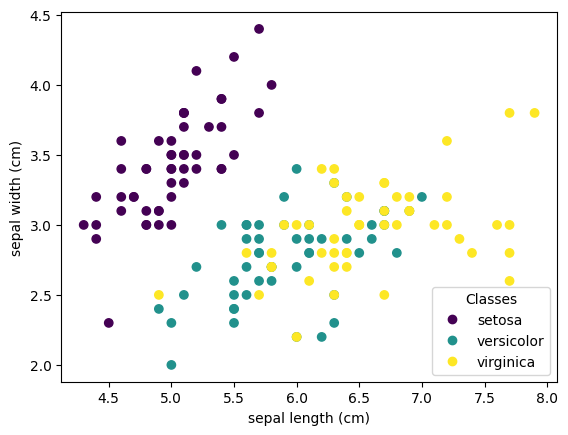

In [3]:
# plotting the dataset
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [5]:
scaler = StandardScaler() # data won't get biased towards any large value
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
k = 5  # could have used any other k value
knn = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.97


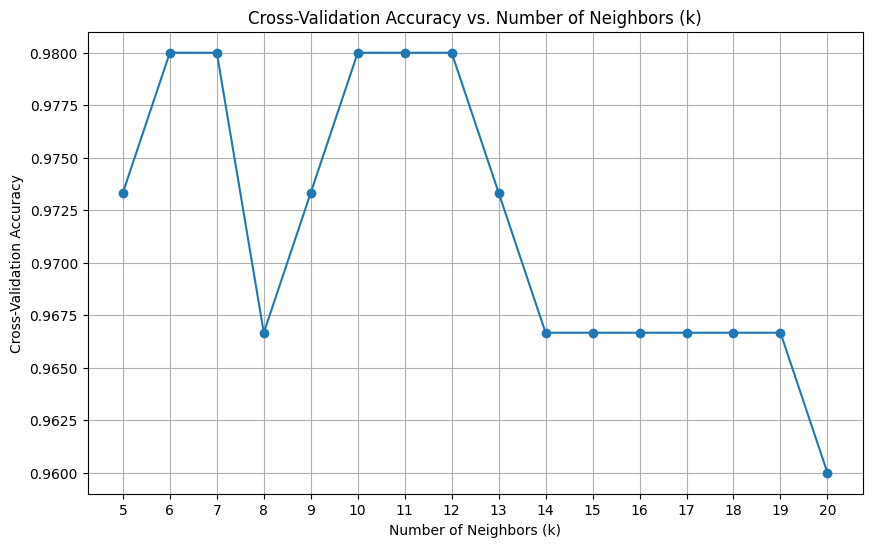

The best k value based on cross-validation is 6 with an accuracy of 0.98


In [8]:
cross_val_accuracies = []
k_values = range(5, 21)

# Cross-validation for each k value
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)  # 5-fold cross-validation, cv=5 is the default value
    cross_val_accuracies.append(np.mean(scores))

# Plot cross-validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Cross-Validation Accuracy vs. Number of Neighbors (k)')
plt.xticks(k_values)
plt.grid()
plt.show()

# Find the best k value based on cross-validation
best_k_cv = k_values[np.argmax(cross_val_accuracies)]
print(f'The best k value based on cross-validation is {best_k_cv} with an accuracy of {max(cross_val_accuracies):.2f}')

# Implementing KNN Classifier from Scratch

In [9]:
class KNN:
    def __init__(self, k):
        # assign the neighbour count
        self.k = k

    def euclidean_distance(self, point1, point2):
        # return the euclidean distance between two points
        return np.sqrt(np.sum((point1 - point2) ** 2))

    def fit(self, X_train, y_train):
        # assign the train data
        self.X_train = X_train
        self.y_train = y_train

    #all test datapoint
    def predict(self, X_test):
        # this method iterates over all the data points in our test dataset and stores their individual labels
        # Hint: during each iteration, you have to call the predict_label method below to get the label
        # returns the prediction of each dataset altogether as an array
        predictions = [self.predict_label(x) for x in X_test]
        return np.array(predictions)

    #this predict_label method will return the most common label for the individual data point called from the predict method
    def predict_label(self, x):
        # Compute distances to all training points
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # Sort by distance and get the indices of the nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get the labels of the nearest neighbors
        k_nearest_labels = self.y_train[k_indices]
        
        # Return the most common class label among the neighbors
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [11]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

# Initialize KNN classifier with the value of n
knn = KNN(3)

# Fit the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy (write down the equation to calculate accuracy, and uncomment the print function)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.91
